In [10]:
import imageio
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk
from skimage.filters import median, threshold_local, rank, threshold_otsu
from skimage import restoration

import torch
import torch.nn as nn

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

home = os.path.expanduser('~')

/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /local-scratch/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


## Model Architecture

In [2]:


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.mid_level = nn.Sequential(
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(96, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(48, out_channels, kernel_size=2, stride=2, output_padding=0)
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.mid_level(x1)
        x3 = self.decoder(x2)

        return x3

# Following two blocks show input and the corresponding mask (ground truth to the model) used in different settings. GT skel denotes the manually annotated ground truth skeleton

## Train with dilated GT skeleton as mask for segmentation

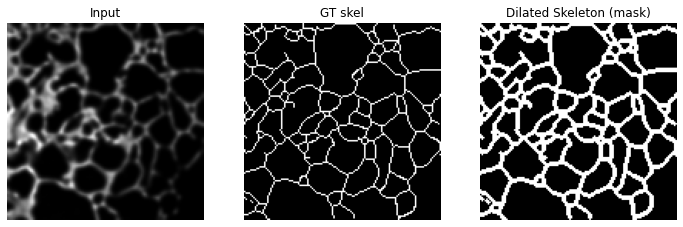

In [55]:
img_path = f'{home}/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp12_er_mean.png'
skel_path = f'{home}/MIAL/data/confocal-data/vess_enh_unet/climp/skel/climp12_proc_skel.png'

img = imageio.imread(img_path)
skel = imageio.imread(skel_path)
gt = dilation(skel)

plt.figure(figsize=(12, 12))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Input')
plt.axis('off')

plt.subplot(132)
plt.imshow(skel, cmap='gray')
plt.title('GT skel')
plt.axis('off')

plt.subplot(133)
plt.imshow(gt, cmap='gray')
plt.title('Dilated Skeleton (mask)')
plt.axis('off')

plt.show()

## Train with GT skel EDT as mask for regression task 

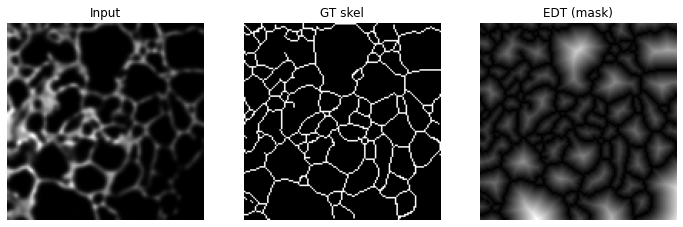

In [52]:
img_path = f'{home}/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp12_er_mean.png'
skel_path = f'{home}/MIAL/data/confocal-data/vess_enh_unet/climp/skel/climp12_proc_skel.png'

img = imageio.imread(img_path)
skel = imageio.imread(skel_path)

edt = distance_transform_edt(np.invert(skel))

plt.figure(figsize=(12, 12))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Input')
plt.axis('off')

plt.subplot(132)
plt.imshow(skel, cmap='gray')
plt.title('GT skel')
plt.axis('off')

plt.subplot(133)
plt.imshow(edt, cmap='gray')
plt.title('EDT (mask)')
plt.axis('off')

plt.show()

## Qualitative results comparison with different models

In [12]:
def get_results(model):
    # example sample
    image_path = '/localhome/asa420/MIAL/data/vess_enh_unet/atl/images/confocal_atl23_er_mean.png'

    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    image_np = image.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())
    return norm

## Different training methods (Same model architecture used for all)

### nerdy_model: Train and test using 80:20 split in Confocal data only (No STED in training).
### skel_edt_model: Euclidean Distance Transform based masks and regression task with Confocal data only.
### confocal_trained_model: Train with complete Confocal data (all 117 samples) and test on STED data (35 samples).
### combined_model: Combine Confocal and STED data as 117+35 samples and then train with 80:20 split on this combined data.

In [5]:
in_channels = 1  # Assuming grayscale images
out_channels = 1  # Assuming binary segmentation output

# Train and test on Confocal with dilated skeleton masks
nerdy_model = UNet(in_channels, out_channels)
nerdy_model.load_state_dict(torch.load('unet_model_48_96.pth'))

# Train and test on Confocal with EDT masks for regression task
skel_edt_model = UNet(in_channels, out_channels)
skel_edt_model.load_state_dict(torch.load('unet_model_skel_edt.pth'))

# Train on full confocal samples, test on STED
confocal_trained_model = UNet(in_channels, out_channels)
confocal_trained_model.load_state_dict(torch.load('unet_model_confocal_train.pth'))

# Combine STED and Confocal data for training and testing as 80:20
combined_model = UNet(in_channels, out_channels)
combined_model.load_state_dict(torch.load('unet_model_combined_train.pth'))



<All keys matched successfully>

In [44]:
nerdy_op = get_results(nerdy_model)
skel_edt_op = get_results(skel_edt_model)
confocal_trained_op = get_results(confocal_trained_model)
combined_model_op = get_results(combined_model)

In [47]:
import copy
from plantcv import plantcv as pcv

def postproc_edt(skel_edt_op):
    skel_edt_op *= -1
    skel_edt_op  = skel_edt_op + (np.min(skel_edt_op) * -1) + (np.min(skel_edt_op) * -1/100)
    skel = postprocessing(skel_edt_op, 0.01)
    return skel

    
def postprocessing(norm, thresh):
    norm_er = erosion(norm)
    rb = restoration.rolling_ball(norm_er)

    subt = norm_er - rb

    subt2 = copy.deepcopy(subt)
    subt2[subt < thresh] = 0.
    subt2[subt >= thresh] = 255.

    skel = pcv.morphology.skeletonize(subt2)
    
    return skel

In [49]:
edt_skel = postproc_edt(skel_edt_op)

nerdy_skel = postprocessing(nerdy_op, 0.1)
confocal_trained_op_skel = postprocessing(confocal_trained_op, 0.1)
combined_model_op_skel = postprocessing(combined_model_op, 0.1)

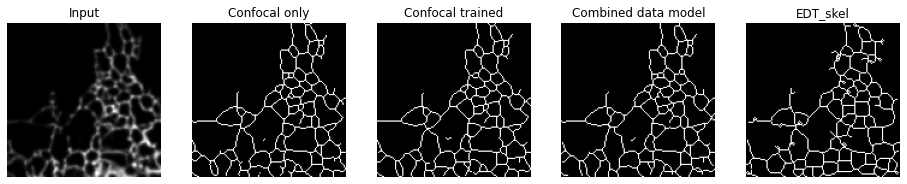

In [54]:
img = imageio.imread('/localhome/asa420/MIAL/data/vess_enh_unet/atl/images/confocal_atl23_er_mean.png')

plt.figure(figsize=(16,16))

plt.subplot(151)
plt.imshow(img, cmap='gray')
plt.title('Input')
plt.axis('off')

plt.subplot(152)
plt.imshow(nerdy_skel, cmap='gray')
plt.title('Confocal only')
plt.axis('off')

plt.subplot(153)
plt.imshow(confocal_trained_op_skel, cmap='gray')
plt.title('Confocal trained')
plt.axis('off')

plt.subplot(154)
plt.imshow(combined_model_op_skel, cmap='gray')
plt.title('Combined data model')
plt.axis('off')

plt.subplot(155)
plt.imshow(edt_skel, cmap='gray')
plt.title('EDT_skel')
plt.axis('off')

plt.show()